# Connect to drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# prompt: connect to my drive the folder name 'ATBMTT'

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ATBMTT
!ls


Mounted at /content/drive
/content/drive/MyDrive/ATBMTT
 AES-GCM.docx			'Giới thiệu.mp4'			       'Tài liệu.gdoc'
 capture1.csv			'Những thứ sẽ cần biết.gdoc'		        test_ws.pcapng
'ChatGPT cứu tôi pha này.gdoc'	 Note.gdoc				       'webserver (1).pcap'
 csv				 simplescreenrecorder-2025-01-08_20.13.29.mp4  'webserver (2).pcap'
 ddos_progress.mp4		 slowloris_packet_capture.csv		       'webserver (3).pcap'
'Đề tài.gdoc'			 slowris_packet_capture.pcap		        webserver.pcap
 dir				 sslfile.log				        ws_capture.csv
 docs				 sslkeyfile


# Clean data


In [ ]:
import pandas as pd
import numpy as np

def format_csv(input_file):
  with open(input_file, "r", encoding="utf-8") as file:
    lines = file.readlines()
  separator = "\t"
  columns = []
  data_rows = []
  current_line = ""
  for line in lines:
    if line.startswith("#separator"):
        continue
    elif line.startswith("#fields"):
      columns = line.split(separator)[1:]

      data_rows.append(columns)
      continue
    elif line.startswith("#"):
        continue
    elif line.endswith("\\"):
        current_line += line[:-1]
    else:
        current_line += line
        data_rows.append(current_line.split(separator))
        current_line = ""
  df = pd.DataFrame(data_rows, columns=columns)
  df.columns = df.columns.str.strip()
  return df


df_ssl = format_csv('/content/drive/MyDrive/ATBMTT/dir/ssl.log')
df_conn = format_csv('/content/drive/MyDrive/ATBMTT/dir/conn.log')

# merge ssl and conn
# merged_df = df_ssl.merge(df_conn, on='ts', how='outer')
merged_df = pd.merge(df_conn, df_ssl, on=["uid"], how="outer")

merged_df = merged_df.map(lambda x: x.strip() if isinstance(x, str) else x)


#merge infor handle
merged_df = merged_df[1: -1]
columns_to_drop = [col for col in merged_df.columns if col.endswith('_y')]

# x,y handle
merged_df = merged_df.drop(columns=columns_to_drop)
merged_df = merged_df.rename(columns=lambda x: x.rstrip('_x'))


merged_df.to_csv('/content/drive/MyDrive/ATBMTT/dir/dataset.csv', index=False)
print(merged_df.columns)

Index(['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
       'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
       'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history',
       'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes',
       'tunnel_parents', 'ip_proto', 'version', 'cipher', 'curve',
       'server_name', 'resumed', 'last_alert', 'next_protocol', 'established',
       'ssl_history', 'cert_chain_fps', 'client_cert_chain_fps',
       'sni_matches_cert'],
      dtype='object')


# Random forest

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#read csv
df = pd.read_csv('/content/drive/MyDrive/ATBMTT/csv/data.csv')

# NULL handle
# df.replace(" ", None, inplace=True)
df.replace("-", None, inplace=True)
# df = df.infer_objects(copy=False)

# df = df.dropna(thresh=df.shape[1] * 0.5)

#feild maybe can use for slowloris detection

#ssl
#established -> handshake failed

#conn
#duration -> timeout request
#orig_bytes -> client send so little data
#orig_pkts -> little packet sent


features = [

]


#datatype handle
df['ts'] = pd.to_datetime(df['ts'], unit='s')
# df['resumed'] = df['resumed'].astype('bool')
# df['established'] = df['established'].astype('bool')
# df["sni_matches_cert"] = df["sni_matches_cert"].astype('bool')
# df['missed_bytes'] = df['missed_bytes'].astype('Int64')
# df['orig_bytes'] = df['orig_bytes'].astype('Int64')
# df['resp_bytes'] = df['resp_bytes'].astype('Int64')
# df['orig_pkts'] = df['orig_pkts'].astype('Int64')
# df['resp_pkts'] = df['resp_pkts'].astype('Int64')
# df['duration'] = df['duration'].astype('float')

# label data with 0: insecure and 1: secure
# df['label'] = 0


# df.loc[(df['established'] == 'F') |
#        (df['resumed'] == 'F') |
#        (df['last_alert'].notna())  |
#        (df["sni_matches_cert"] == 'F'), 'label'] = 1

# df.to_csv('/content/drive/MyDrive/ATBMTT/csv/cleaned.csv', index=False)
print(df.co)



In [ ]:
import pandas as pd
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
%matplotlib inline



In [ ]:
#read csv
df = pd.read_csv('/content/drive/MyDrive/ATBMTT/csv/clean_dataset.csv')
df.head()
df.columns

Index(['Unnamed: 0', 'proto', 'service', 'id.resp_p', 'missed_bytes',
       'version', 'cipher', 'curve', 'resumed', 'last_alert', 'established',
       'sni_matches_cert', 'username', 'password',
       'certificate.not_valid_before', 'certificate.not_valid_after',
       'certificate.key_alg', 'certificate.sig_alg', 'certificate.key_length',
       'certificate.key', 'secure_label'],
      dtype='object')

In [ ]:
# Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27824 entries, 0 to 27823
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    27824 non-null  int64  
 1   proto                         26063 non-null  object 
 2   service                       1153 non-null   object 
 3   id.resp_p                     26063 non-null  float64
 4   missed_bytes                  26063 non-null  float64
 5   version                       27824 non-null  int64  
 6   cipher                        27824 non-null  int64  
 7   curve                         27824 non-null  int64  
 8   resumed                       27824 non-null  int64  
 9   last_alert                    0 non-null      float64
 10  established                   27824 non-null  int64  
 11  sni_matches_cert              27824 non-null  int64  
 12  username                      27824 non-null  int64  
 13  p

In [ ]:
#Check null values
df.head()
df = df.drop(['Unnamed: 0','proto', 'service', 'id.resp_p', 'certificate.key_alg'], axis=1)
df.isnull().sum()

,0
missed_bytes,1761
version,0
cipher,0
curve,0
resumed,0
last_alert,27824
established,0
sni_matches_cert,0
username,0
password,0


In [ ]:
# Drop some non-valuable column, i guess so:D

# ['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
#       'version', 'cipher', 'curve', 'server_name', 'resumed', 'last_alert',
#       'next_protocol', 'established', 'ssl_history', 'cert_chain_fps',
#       'client_cert_chain_fps', 'sni_matches_cert', 'label']

df.head()

,missed_bytes,version,cipher,curve,resumed,last_alert,established,sni_matches_cert,username,password,certificate.not_valid_before,certificate.not_valid_after,certificate.sig_alg,certificate.key_length,certificate.key,secure_label
0,0.0,1,1,1,1,NaN,1,1,1,1,1,1,1,NaN,1,1
1,0.0,1,1,1,1,NaN,1,1,1,1,1,1,1,NaN,1,1
2,0.0,1,1,1,1,NaN,1,1,1,1,1,1,1,NaN,1,1
3,0.0,1,1,1,1,NaN,1,1,1,1,1,1,1,NaN,1,1
4,0.0,1,1,1,1,NaN,1,1,1,1,1,1,1,NaN,1,1


In [ ]:
# Import train_test_split function
from sklearn.model_selection import train_test_split
label='secure_label'
X = df.drop([label], axis = 1) # axis = 1 <=> column
Y = df[label]

# Split dataset into training set and test subset
# random_state - seed for random generation to ensure the randomized output is the same after each code execution
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # 80% training and 20% tes

In [ ]:
# Check shape of X_train and Y_train
X_train.shape, X_test.shape

((22259, 15), (5565, 15))

In [ ]:
# Feature Engineering is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power.

# datatype
X_train.dtypes

# Detail of X_train subset
# X_train.head()

,0
missed_bytes,float64
version,int64
cipher,int64
curve,int64
resumed,int64
last_alert,float64
established,int64
sni_matches_cert,int64
username,int64
password,int64


In [ ]:
#Import Random Forest Model
from sklearn.ensemble import RandomForestClassifier

#Create a Gaussian Classifier
# Specific how much decisional tree is used( in this ex is 10 trees)
clf=RandomForestClassifier(random_state=42,n_estimators=100)

#Train the model using the training sets
#Fit model
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
print('Accuracy: {0:0.4f}'.format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.9626


Feature (variable) importance indicates how much each feature contributes to the model prediction. Basically, it determines the degree of usefulness of a pecific variable for a current model and prediction.

In [ ]:
# Extract extract feature importances
feature_scores = pd.Series(clf.feature_importances_, index = X_train.columns).sort_values(ascending=False)
feature_scores


,0
downgrade,0.941940
weak_cipher_suite,0.044884
Unnamed: 0,0.011054
expired_certificate,0.001206
sensitive_http,0.000916
certificate,0.000000
subject,0.000000
issuer,0.000000
weak_tls_version,0.000000


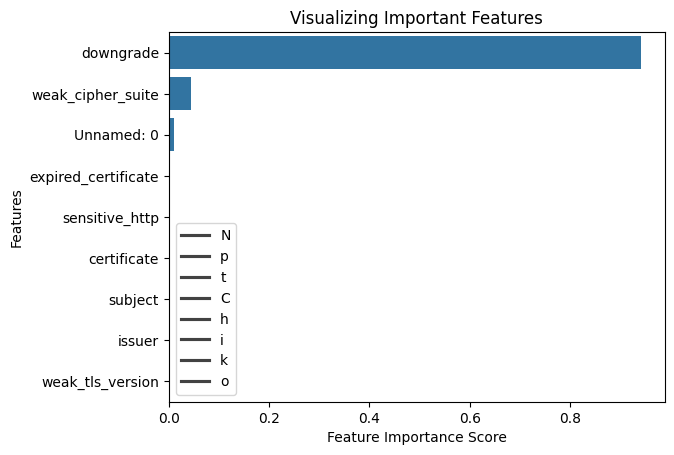

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Creating a bar plot
sns.barplot(x = feature_scores, y = feature_scores.index)

# Add labels to your graph
plt.xlabel('Feature Importance Score')

plt.ylabel('Features')
plt.legend('NptChiko')
plt.title("Visualizing Important Features")

plt.show()


Build RandomForest model with valuable features

In [ ]:
# Import train_test_split function
# Split dataset into features and labels

X = df.drop([], axis = 1)
Y = df[]

# Split dataset into training set and test set`
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # 70% training and 30% test

SyntaxError: invalid syntax (<ipython-input-29-8e077194259b>, line 5)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#Create a Gaussian Classifier
#Train with 100 decisional trees
clf = RandomForestClassifier(random_state=42, n_estimators=100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)
# prediction on test set`
y_pred=clf.predict(X_test)
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?`
print('Accuracy of model with valuable features: {0:0.4}'.format(metrics.accuracy_score(y_test, y_pred)))


Accuracy of model with valuable features: 1.0




A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.

Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-

True Positives (TP) – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.

True Negatives (TN) – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.

False Positives (FP) – False Positives occur when we predict an observation belongs to a certain class but the observation actually does not belong to that class. This type of error is called Type I error.

False Negatives (FN) – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called Type II error.


In [ ]:
#Print confusion matrix   and slice it into four pieces
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[79905     0]
 [    0    95]]


The rows represent the true labels and the columns represent predicted labels. Values on the diagonal represent the number (or percent, in a normalized confusion matrix) of times where the predicted label matches the true label. Values in the other cells represent instances where the classifier mislabeled an observation; the column tells us what the classifier predicted, and the row tells us what the right label was.bold text

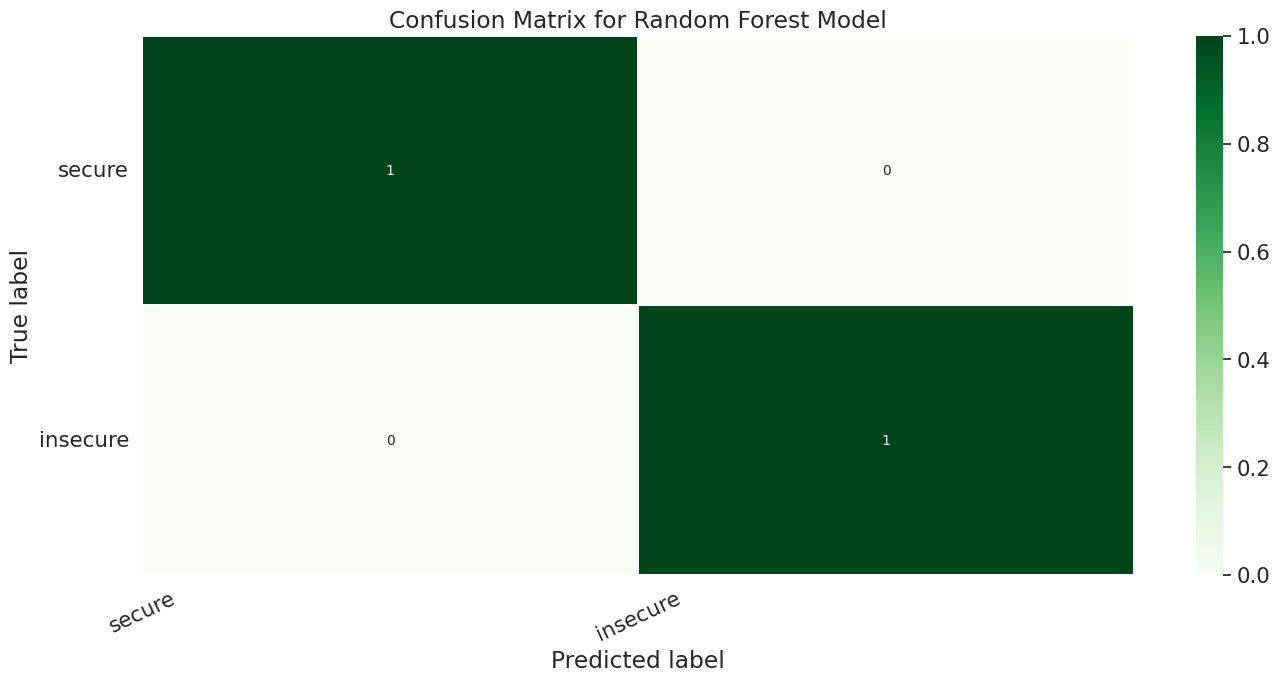

In [ ]:
# Beautify confusion matrix
# Get and reshape confusion matrix data
matrix = confusion_matrix(y_test, y_pred)
matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

# Build the plot
plt.figure(figsize=(16,7))
sns.set(font_scale=1.4)
sns.heatmap(matrix, annot=True, annot_kws={'size':10},
            cmap=plt.cm.Greens, linewidths=0.2)

# Add labels to the plot
class_names = ['secure', 'insecure']
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5
plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()


Report overrall result and performance of algorithm

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     79905
           1       1.00      1.00      1.00        95

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000



# New Section